# Fall Detection — SVM Modeling Pipeline
**Input:** `preprocessed_chest.pkl` dari notebook preprocessing
**Target:** duduk, jalan, jatuh, tidur

### Kondisi dataset yang diketahui:
- Total windows : 2028
- Imbalance     : 3.8x (jatuh 46%, tidur 12%)
- Fitur         : 44
- Strategi      : StandardScaler + SVM RBF + class_weight='balanced' + StratifiedKFold

## STEP 0 — Install & Import

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install scikit-learn imbalanced-learn -q

import pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    StratifiedKFold, cross_validate,
    GridSearchCV, learning_curve
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from collections import Counter

print('Import OK')

Import OK


## STEP 1 — Load Data Hasil Preprocessing

In [ ]:
with open('/content/drive/MyDrive/uma_fall_data/preprocessed_chest.pkl', 'rb') as f:
    data = pickle.load(f)

X   = data['X']             # (2028, 44)
y   = data['y']             # encoded int
le  = data['label_encoder']
classes = data['classes']   # ['duduk','jalan','jatuh','tidur']

print(f'X shape  : {X.shape}')
print(f'y shape  : {y.shape}')
print(f'Kelas    : {classes}')
print()
print('Distribusi:')
for i, cls in enumerate(le.classes_):
    cnt = np.sum(y == i)
    print(f'  {i} {cls:8s}: {cnt} ({100*cnt/len(y):.1f}%)')

X shape  : (2028, 44)
y shape  : (2028,)
Kelas    : [np.str_('duduk'), np.str_('jalan'), np.str_('jatuh'), np.str_('tidur')]

Distribusi:
  0 duduk   : 285 (14.1%)
  1 jalan   : 566 (27.9%)
  2 jatuh   : 933 (46.0%)
  3 tidur   : 244 (12.0%)


## STEP 2 — Cek & Tangani Missing Value / Infinite
*(seharusnya bersih dari preprocessing, tapi validasi dulu)*

In [ ]:
print('NaN  :', np.isnan(X).sum())
print('Inf  :', np.isinf(X).sum())

# Ganti jika ada
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
print('Bersih: OK')

NaN  : 0
Inf  : 0
Bersih: OK


## STEP 3 — Stratified Train/Test Split

> Kita pisah **20% data sebagai test set final** (tidak disentuh selama training).
> Evaluasi utama pakai **StratifiedKFold-5** pada train set.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # jaga proporsi tiap kelas
)

print(f'Train: {X_train.shape[0]} window')
print(f'Test : {X_test.shape[0]} window')
print()
print('Distribusi train:')
for i, cls in enumerate(le.classes_):
    print(f'  {cls}: {np.sum(y_train==i)}')
print()
print('Distribusi test:')
for i, cls in enumerate(le.classes_):
    print(f'  {cls}: {np.sum(y_test==i)}')

Train: 1622 window
Test : 406 window

Distribusi train:
  duduk: 228
  jalan: 453
  jatuh: 746
  tidur: 195

Distribusi test:
  duduk: 57
  jalan: 113
  jatuh: 187
  tidur: 49


## STEP 4 — Baseline SVM (tanpa tuning)

Pipeline: **StandardScaler → SMOTE → SVM RBF**

SMOTE hanya diterapkan di dalam training fold (tidak bocor ke validation).

In [ ]:
# Pipeline dengan SMOTE di dalam cross-validation
baseline_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=42, k_neighbors=3)),
    ('svm',    SVC(
                   kernel='rbf',
                   C=1.0,
                   gamma='scale',
                   class_weight='balanced',
                   random_state=42,
                   probability=True
               ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Menjalankan Baseline CV (5-fold)...')
baseline_cv = cross_validate(
    baseline_pipe, X_train, y_train,
    cv=cv,
    scoring=['accuracy', 'f1_macro', 'f1_weighted'],
    n_jobs=-1
)

print()
print('BASELINE SVM — Cross Validation Results:')
print(f'  Accuracy   : {baseline_cv["test_accuracy"].mean():.4f} ± {baseline_cv["test_accuracy"].std():.4f}')
print(f'  F1 Macro   : {baseline_cv["test_f1_macro"].mean():.4f} ± {baseline_cv["test_f1_macro"].std():.4f}')
print(f'  F1 Weighted: {baseline_cv["test_f1_weighted"].mean():.4f} ± {baseline_cv["test_f1_weighted"].std():.4f}')

Menjalankan Baseline CV (5-fold)...

BASELINE SVM — Cross Validation Results:
  Accuracy   : 0.9248 ± 0.0082
  F1 Macro   : 0.8946 ± 0.0098
  F1 Weighted: 0.9261 ± 0.0084


## STEP 5 — Hyperparameter Tuning (GridSearchCV)

Cari kombinasi C dan gamma terbaik.
Grid yang dipakai efisien — tidak terlalu besar agar tidak lama.

In [ ]:
param_grid = {
    'svm__C'    : [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.01, 0.001],
}

# Pakai pipeline yang sama (dengan SMOTE)
tune_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=42, k_neighbors=3)),
    ('svm',    SVC(
                   kernel='rbf',
                   class_weight='balanced',
                   random_state=42,
                   probability=True
               ))
])

grid_search = GridSearchCV(
    tune_pipe,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',   # fokus ke keseimbangan antar kelas
    n_jobs=-1,
    verbose=1
)

print('Menjalankan GridSearchCV (4x4 x 5-fold = 80 fits)...')
print('Estimasi: 3-8 menit tergantung CPU Colab')
grid_search.fit(X_train, y_train)

print()
print(f'Best params : {grid_search.best_params_}')
print(f'Best F1 macro (CV): {grid_search.best_score_:.4f}')

Menjalankan GridSearchCV (4x4 x 5-fold = 80 fits)...
Estimasi: 3-8 menit tergantung CPU Colab
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best params : {'svm__C': 10, 'svm__gamma': 0.01}
Best F1 macro (CV): 0.8978


## STEP 6 — Evaluasi Model Terbaik di Test Set

In [ ]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)

print('=' * 55)
print('       HASIL EVALUASI — TEST SET (20%)')
print('=' * 55)
print()
print(classification_report(
    y_test, y_pred,
    target_names=le.classes_,
    digits=4
))

# AUC (One-vs-Rest)
try:
    auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
    print(f'AUC (macro OvR): {auc:.4f}')
except Exception as e:
    print(f'AUC: {e}')

       HASIL EVALUASI — TEST SET (20%)

              precision    recall  f1-score   support

       duduk     0.7656    0.8596    0.8099        57
       jalan     0.9524    0.8850    0.9174       113
       jatuh     0.9789    0.9947    0.9867       187
       tidur     0.9574    0.9184    0.9375        49

    accuracy                         0.9360       406
   macro avg     0.9136    0.9144    0.9129       406
weighted avg     0.9390    0.9360    0.9367       406

AUC (macro OvR): 0.9893


## STEP 7 — Confusion Matrix

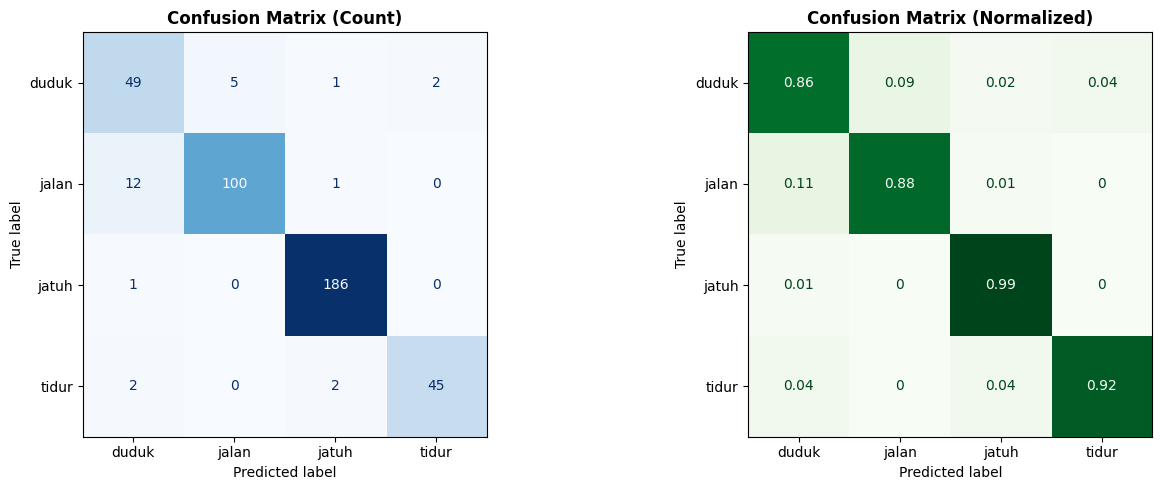

Tersimpan: /content/drive/MyDrive/uma_fall_data/data/confusion_matrix.png


In [ ]:
import os

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
cm = confusion_matrix(y_test, y_pred)
disp1 = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp1.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Count)', fontsize=12, fontweight='bold')

# Normalized
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
disp2 = ConfusionMatrixDisplay(np.round(cm_norm,2), display_labels=le.classes_)
disp2.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=12, fontweight='bold')

plt.tight_layout()

# Create the directory if it doesn't exist
output_dir = '/content/drive/MyDrive/uma_fall_data/data/'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, 'confusion_matrix.png'), dpi=130)
plt.show()
print('Tersimpan: /content/drive/MyDrive/uma_fall_data/data/confusion_matrix.png')

## STEP 8 — Feature Importance (via Permutation)

SVM tidak punya feature importance bawaan.
Kita pakai **permutation importance** — cepat dan akurat.

Menghitung permutation importance (sebentar)...


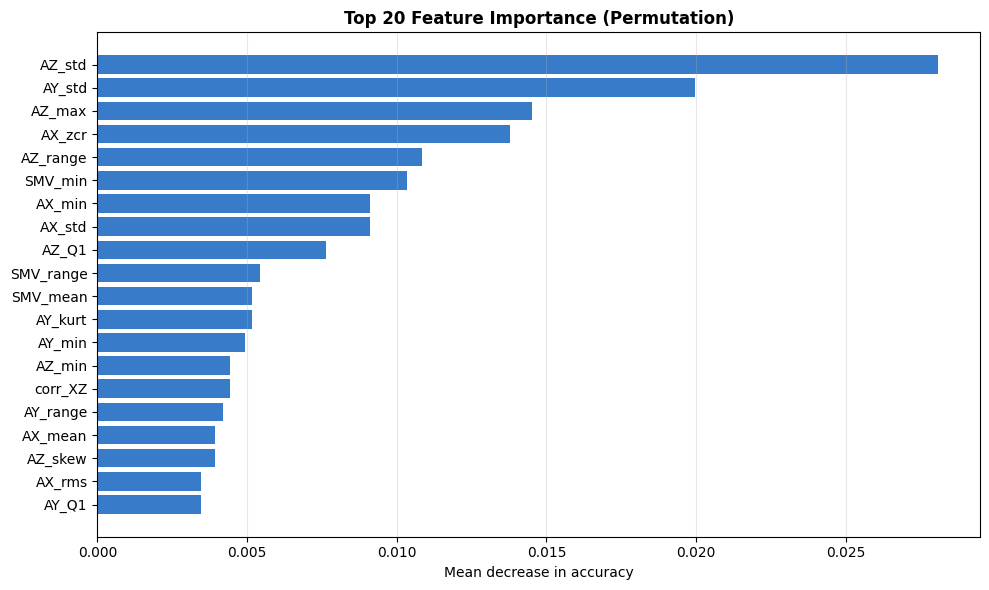

Tersimpan: /content/drive/MyDrive/uma_fall_data/data/feature_importance.png


In [ ]:
from sklearn.inspection import permutation_importance

# Buat pipeline tanpa SMOTE untuk permutation (pakai test set)
# Fit scaler saja dulu
scaler_only = StandardScaler()
X_train_sc = scaler_only.fit_transform(X_train)
X_test_sc  = scaler_only.transform(X_test)

# Ambil SVM dari best model dan fit ulang tanpa SMOTE
# (karena permutation butuh predict langsung)
best_C     = grid_search.best_params_['svm__C']
best_gamma = grid_search.best_params_['svm__gamma']

svm_direct = SVC(
    kernel='rbf', C=best_C, gamma=best_gamma,
    class_weight='balanced', random_state=42, probability=True
)
svm_direct.fit(X_train_sc, y_train)

print('Menghitung permutation importance (sebentar)...')
perm = permutation_importance(
    svm_direct, X_test_sc, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

# Nama fitur (sesuai urutan di extract_features)
axis_names = ['AX','AY','AZ']
stat_names = ['mean','std','min','max','range','skew','kurt','rms','Q1','Q3']
feat_names = []
for ax in axis_names:
    for s in stat_names:
        feat_names.append(f'{ax}_{s}')
feat_names += ['SMV_mean','SMV_std','SMV_max','SMV_min','SMV_range',
               'SMV_skew','SMV_kurt','SMV_rms']
feat_names += [f'{ax}_zcr' for ax in axis_names]
feat_names += ['corr_XY','corr_XZ','corr_YZ']

# Top 20 fitur
imp_mean = perm.importances_mean
top_idx  = np.argsort(imp_mean)[::-1][:20]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    [feat_names[i] for i in top_idx[::-1]],
    imp_mean[top_idx[::-1]],
    color='#1565C0', alpha=0.85
)
ax.set_title('Top 20 Feature Importance (Permutation)', fontsize=12, fontweight='bold')
ax.set_xlabel('Mean decrease in accuracy')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/uma_fall_data/data/feature_importance.png', dpi=130)
plt.show()
print('Tersimpan: /content/drive/MyDrive/uma_fall_data/data/feature_importance.png')

## STEP 9 — Simpan Model Final (.pkl)

In [ ]:
MODEL_PATH = '/content/drive/MyDrive/uma_fall_data/data/fall_detection_svm.pkl'

# Simpan best model (sudah include scaler+smote+svm dalam pipeline)
with open(MODEL_PATH, 'wb') as f:
    pickle.dump({
        'model'         : best_model,
        'label_encoder' : le,
        'classes'       : list(le.classes_),
        'best_params'   : grid_search.best_params_,
        'best_cv_score' : grid_search.best_score_,
        'feature_names' : feat_names,
        'n_features'    : 44,
        'window_size'   : 100,
        'fs'            : 20,
    }, f)

import os
size_kb = os.path.getsize(MODEL_PATH) / 1024
print(f'Model tersimpan : {MODEL_PATH}')
print(f'Ukuran file     : {size_kb:.1f} KB')
print(f'Best params     : {grid_search.best_params_}')
print(f'Kelas           : {list(le.classes_)}')

Model tersimpan : /content/drive/MyDrive/uma_fall_data/data/fall_detection_svm.pkl
Ukuran file     : 273.3 KB
Best params     : {'svm__C': 10, 'svm__gamma': 0.01}
Kelas           : [np.str_('duduk'), np.str_('jalan'), np.str_('jatuh'), np.str_('tidur')]


## STEP 10 — Laporan Akhir & Cara Pakai Model

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

acc  = accuracy_score(y_test, y_pred)
f1m  = f1_score(y_test, y_pred, average='macro')
f1w  = f1_score(y_test, y_pred, average='weighted')

print('='*56)
print('         LAPORAN MODEL FINAL')
print('='*56)
print(f'  Algoritma        : SVM (RBF kernel)')
print(f'  Best C           : {grid_search.best_params_["svm__C"]}')
print(f'  Best gamma       : {grid_search.best_params_["svm__gamma"]}')
print(f'  Scaler           : StandardScaler')
print(f'  Imbalance handler: SMOTE + class_weight=balanced')
print(f'  Validasi         : StratifiedKFold-5')
print()
print(f'  --- Test Set Results ---')
print(f'  Accuracy         : {acc:.4f} ({acc*100:.2f}%)')
print(f'  F1 Macro         : {f1m:.4f}')
print(f'  F1 Weighted      : {f1w:.4f}')
print('='*56)

         LAPORAN MODEL FINAL
  Algoritma        : SVM (RBF kernel)
  Best C           : 10
  Best gamma       : 0.01
  Scaler           : StandardScaler
  Imbalance handler: SMOTE + class_weight=balanced
  Validasi         : StratifiedKFold-5

  --- Test Set Results ---
  Accuracy         : 0.9360 (93.60%)
  F1 Macro         : 0.9129
  F1 Weighted      : 0.9367


In [ ]:
# ── Contoh cara pakai model untuk prediksi baru ─────────────────
print('CARA PAKAI MODEL:')
print('''
import pickle, numpy as np
from scipy import stats

# Load model
with open('fall_detection_svm.pkl', 'rb') as f:
    bundle = pickle.load(f)
model = bundle['model']
le    = bundle['label_encoder']

# Siapkan window baru: shape (100, 3) → ax, ay, az chest
def extract_features(win):
    # ... (sama persis dengan fungsi di notebook preprocessing)
    pass

window = np.random.randn(100, 3).astype(np.float32)  # contoh
feat   = extract_features(window).reshape(1, -1)

pred_enc  = model.predict(feat)[0]
pred_prob = model.predict_proba(feat)[0]
pred_label = le.inverse_transform([pred_enc])[0]

print(f"Prediksi : {pred_label}")
print(f"Confidence: {pred_prob.max():.2%}")
''')

CARA PAKAI MODEL:

import pickle, numpy as np
from scipy import stats

# Load model
with open('fall_detection_svm.pkl', 'rb') as f:
    bundle = pickle.load(f)
model = bundle['model']
le    = bundle['label_encoder']

# Siapkan window baru: shape (100, 3) → ax, ay, az chest
def extract_features(win):
    # ... (sama persis dengan fungsi di notebook preprocessing)
    pass

window = np.random.randn(100, 3).astype(np.float32)  # contoh
feat   = extract_features(window).reshape(1, -1)

pred_enc  = model.predict(feat)[0]
pred_prob = model.predict_proba(feat)[0]
pred_label = le.inverse_transform([pred_enc])[0]

print(f"Prediksi : {pred_label}")
print(f"Confidence: {pred_prob.max():.2%}")

